In [4]:
import pandas as pd
from itertools import combinations

# 读取数据
data = pd.read_csv('./data/all-country.csv')

# 创建文档作者国家的交叉表
cross_table = pd.crosstab(index=data['Document_ID'], columns=data['Country'])

# 获取所有不同的国家
countries = list(cross_table.columns)

# 计算存在合作的国家对的合作次数
cooperation_counts = {}
for country1, country2 in combinations(countries, 2):
    cooperation_count = cross_table[(cross_table[country1] > 0) & (cross_table[country2] > 0)]
    count = len(cooperation_count)
    if count > 0:
        cooperation_counts[(country1, country2)] = count

# 输出存在合作的国家对及其合作次数
for (country1, country2), count in cooperation_counts.items():
    print(f"Cooperation count between {country1} and {country2}: {count}")


Cooperation count between A. Wren and Canada: 1
Cooperation count between A. Wren and USA: 1
Cooperation count between AUSTRALIA and PEOPLES R CHINA: 1
Cooperation count between AUSTRALIA and SOUTH AFRICA: 1
Cooperation count between AUSTRALIA and UK: 1
Cooperation count between Aamir Firoz and Muhammad: 1
Cooperation count between Aamir Firoz and Pakistan: 1
Cooperation count between Abdul and Malaysia: 1
Cooperation count between Abdul and Peoples R China: 1
Cooperation count between Abdul and Rozaimah: 1
Cooperation count between Abdul Ghafar and Bayu Taufiq: 1
Cooperation count between Abdul Ghafar and Malaysia: 1
Cooperation count between Abdulgawi Salim and Belgium: 2
Cooperation count between Abdulgawi Salim and Brazil: 2
Cooperation count between Abdulgawi Salim and Brigitte: 2
Cooperation count between Abdulgawi Salim and Canada: 2
Cooperation count between Abdulgawi Salim and Egypt: 2
Cooperation count between Abdulgawi Salim and France: 2
Cooperation count between Abdulgawi 

Cooperation count between Sareh and Slovenia: 1
Cooperation count between Sareh and UK: 1
Cooperation count between Saskia and UK: 1
Cooperation count between Saudi Arabia and Taiwan: 1
Cooperation count between Saudi Arabia and U Arab Emirates: 1
Cooperation count between Saudi Arabia and UK: 5
Cooperation count between Saudi Arabia and USA: 6
Cooperation count between Scott and USA: 2
Cooperation count between Scott and Victoria: 1
Cooperation count between Scott John and Spain: 1
Cooperation count between Scott John and USA: 2
Cooperation count between Sean and Seong-Hyun: 1
Cooperation count between Sean and USA: 3
Cooperation count between Sebastian and USA: 2
Cooperation count between Sebastien and Switzerland: 1
Cooperation count between Sebnem and South Korea: 1
Cooperation count between Sebnem and Turkey: 3
Cooperation count between Sebnem and USA: 2
Cooperation count between Sefa and USA: 1
Cooperation count between Selma and UK: 1
Cooperation count between Semra and Turkey: 

# 合作统计

In [32]:
import pandas as pd

# 读取 all-country.csv 文件
all_country_data = pd.read_csv('./data/all-country.csv')

# 读取 pub-year.xlsx 文件
pub_year_data = pd.read_excel('./data/pub-year.xlsx')

# 合并两个数据集
merged = pd.merge(all_country_data, pub_year_data, on='Document_ID')

# 计算每年的总发文量
total_papers = merged.groupby('Year').size()

# 计算每年的合作发文数量
collaborative_papers = merged[merged.duplicated('Document_ID', keep=False)].groupby('Year').size()

# 获取所有年份
all_years = merged['Year'].unique()

# 对于没有合作发文的年份，填充0
collaborative_papers = collaborative_papers.reindex(all_years, fill_value=0)

# 计算每年的独立发文数量
independent_papers = total_papers - collaborative_papers

# 计算合作的百分比
collaboration_percentage = (collaborative_papers / total_papers) * 100

# 输出结果
print('Total papers per year:\n', total_papers)
print('Collaborative papers per year:\n', collaborative_papers)
print('Independent papers per year:\n', independent_papers)
print('Collaboration percentage per year:\n', collaboration_percentage)

# 将结果合并为一个数据框
result_data = pd.DataFrame({
    'Year': collaborative_papers.index, 
    'Total Documents': total_papers.values,
    'Coauthored Documents': collaborative_papers.values,
    'Independent Documents': independent_papers.values,
    'Cooperation Percentage': cooperation_percentage
})

# 将结果保存到 CSV 文件
result_data.to_csv('./data/document_statistics_over_time.csv', index=False)

Total papers per year:
 Year
1982       3
1983       5
1984      23
1985      28
1986      19
1987      18
1988      36
1989      52
1990      39
1991      46
1992      40
1993      47
1994      54
1995      48
1996      49
1997      70
1998     194
1999     215
2000     236
2001     268
2002     308
2003     346
2004     374
2005     339
2006     321
2007     379
2008     783
2009    1090
2010     869
2011     796
2012     660
2013     865
2014     820
2015     934
2016     926
2017     885
2018    1323
2019    1310
2020     972
2021     927
2022     924
2023     654
dtype: int64
Collaborative papers per year:
 Year
1982       0
1983       0
1984      14
1985      12
1986       8
1987       4
1988      15
1989      23
1990      15
1991      22
1992      11
1995      26
1996      15
1997      22
1998      92
1999     123
2000     125
2001     144
2002     172
1993      20
1994      27
2003     216
2004     225
2005     203
2006     189
2007     253
2008     649
2009     866
2010     75

In [2]:
import pandas as pd
from itertools import combinations

# 读取数据
data = pd.read_csv('./data/all-country.csv')

# 获取文章编号和对应的国家列表
article_countries = data.groupby('Document_ID')['Country'].apply(list).reset_index()

# 计算每个国家的合作次数
cooperation_counts = {}
for countries_list in article_countries['Country']:
    for country1, country2 in combinations(countries_list, 2):
        # 排序确保同一组合的顺序一致，以避免重复计数
        pair = tuple(sorted([country1, country2]))
        cooperation_counts[pair] = cooperation_counts.get(pair, 0) + 1

# 创建 DataFrame
result_df = pd.DataFrame(list(cooperation_counts.items()), columns=['Country_Pair', 'Cooperation_Count'])

# 将结果保存为 CSV 文件
result_df.to_csv('cooperation_counts_per_country_pair.csv', index=False)


指标

In [15]:
import pandas as pd

# Load the data
cooperation_data = pd.read_csv('./data/cooperation_counts_per_country_pair.csv')
article_counts_data = pd.read_csv('./data/country_article_counts.csv')

# Merge the two datasets based on country names
merged_data = pd.merge(cooperation_data, article_counts_data, how='inner', left_on='Country_1', right_on='Country')

# Rename columns for clarity
merged_data = merged_data.rename(columns={'Total Articles': 'Total_Articles_Country_1'})
merged_data = merged_data.drop('Country', axis=1)

# Merge again for the second country
merged_data = pd.merge(merged_data, article_counts_data, how='inner', left_on='Country_2', right_on='Country')

# Rename columns for clarity
merged_data = merged_data.rename(columns={'Total Articles': 'Total_Articles_Country_2'})
merged_data = merged_data.drop('Country', axis=1)

# Calculate cooperation strength indicator Int_ij
merged_data['Int_ij'] = (merged_data['Cooperation_Count'] ** 2) / (merged_data['Total_Articles_Country_1'] * merged_data['Total_Articles_Country_2'])

# Display the result
print(merged_data[['Country_1', 'Country_2', 'Cooperation_Count', 'Int_ij']])
merged_data.to_csv('./data/cooperation_intensity_per_country_pair.csv', index=False)

           Country_1      Country_2  Cooperation_Count    Int_ij
0             CANADA         CANADA                 11  0.046521
1             CANADA            USA                 11  0.000368
2                USA            USA               3663  0.323621
3                 UK            USA                269  0.007756
4          SINGAPORE            USA                  1  0.000078
...              ...            ...                ...       ...
4671  Emmeke Barbara       Gabriela                  1  1.000000
4672         Daniele       Frederic                  1  1.000000
4673   Samuel Petros  Samuel Petros                  1  0.250000
4674           Aimin            Hao                  1  0.500000
4675            Chen         Dayuan                  1  0.500000

[4676 rows x 4 columns]


In [17]:
import pandas as pd

# Load the data
cooperation_data = pd.read_csv('./data/cooperation_counts_per_country_pair.csv')
article_counts_data = pd.read_csv('./data/country_article_counts.csv')

# Merge the two datasets based on country names
merged_data = pd.merge(cooperation_data, article_counts_data, how='inner', left_on='Country_1', right_on='Country')

# Rename columns for clarity
merged_data = merged_data.rename(columns={'Total Articles': 'Total_Articles_Country_1'})
merged_data = merged_data.drop('Country', axis=1)

# Merge again for the second country
merged_data = pd.merge(merged_data, article_counts_data, how='inner', left_on='Country_2', right_on='Country')

# Rename columns for clarity
merged_data = merged_data.rename(columns={'Total Articles': 'Total_Articles_Country_2'})
merged_data = merged_data.drop('Country', axis=1)

# Calculate cooperation strength indicator Int_ij
merged_data['Int_ij'] = (merged_data['Cooperation_Count'] ** 2) / (merged_data['Total_Articles_Country_1'] * merged_data['Total_Articles_Country_2'])

# Calculate k_i and k_j
k_values = merged_data.groupby('Country_1')['Country_2'].nunique().reset_index()
k_values = k_values.rename(columns={'Country_2': 'k_i'})
merged_data = pd.merge(merged_data, k_values, how='left', on='Country_1')

k_values = merged_data.groupby('Country_2')['Country_1'].nunique().reset_index()
k_values = k_values.rename(columns={'Country_1': 'k_j'})
merged_data = pd.merge(merged_data, k_values, how='left', on='Country_2')

# Calculate cooperation strength similarity index Sim_ij
merged_data['Sim_ij'] = (merged_data['Int_ij'] * (1 / (merged_data['k_i'] * merged_data['k_j']))) ** 0.5

# Display the result
print(merged_data[['Country_1', 'Country_2', 'Cooperation_Count', 'Sim_ij']])
merged_data.to_csv('./data/cooperation_sim_per_country_pair.csv', index=False)

           Country_1      Country_2  Cooperation_Count    Sim_ij
0             CANADA         CANADA                 11  0.152513
1             CANADA            USA                 11  0.000608
2                USA            USA               3663  0.003715
3                 UK            USA                269  0.000860
4          SINGAPORE            USA                  1  0.000394
...              ...            ...                ...       ...
4671  Emmeke Barbara       Gabriela                  1  0.204124
4672         Daniele       Frederic                  1  0.577350
4673   Samuel Petros  Samuel Petros                  1  0.353553
4674           Aimin            Hao                  1  0.353553
4675            Chen         Dayuan                  1  0.408248

[4676 rows x 4 columns]


In [18]:
# Save cooperation breadth to a CSV file
cooperation_breadth = merged_data[['Country_1', 'k_i']].rename(columns={'Country_1': 'Country', 'k_i': 'Cooperation_Breadth'})
cooperation_breadth.to_csv('./data/cooperation_breadth.csv', index=False)


In [19]:
import pandas as pd

# Load the cooperation data
cooperation_data = pd.read_csv('./data/cooperation_counts_per_country_pair.csv')

# Group by each country and sum the cooperation counts
total_cooperation_count = cooperation_data.groupby('Country_1')['Cooperation_Count'].sum().reset_index()
total_cooperation_count = total_cooperation_count.rename(columns={'Country_1': 'Country', 'Cooperation_Count': 'Total_Cooperation_Count'})

# Save the result to a CSV file
total_cooperation_count.to_csv('./data/total_cooperation_count.csv', index=False)


# 发文量统计

In [10]:
import pandas as pd

# 读取数据
data = pd.read_csv('./data/all-country.csv')  # 包含国家名称的 CSV 文件路径

# 统计每个国家的发文量
country_article_counts = data['Country'].value_counts()

# 将结果保存到 CSV 文件
country_article_counts.to_csv('./data/country_article_counts.csv', header=['Total Articles'])


In [7]:
import pandas as pd

# 读取数据
data = pd.read_csv('./data/all-country.csv')  # 替换为你的 Excel 文件路径

# 创建文档作者国家的交叉表
cross_table = pd.crosstab(index=data['Document_ID'], columns=data['Country'])

# 获取所有不同的国家
countries = list(cross_table.columns)

# 计算每个国家的论文数
papers_count = cross_table.sum(axis=0)

# 计算合作强度指标
intensity_index = {}
for country1, country2 in combinations(countries, 2):
    papers_coauthored = cross_table[(cross_table[country1] > 0) & (cross_table[country2] > 0)]
    pij = len(papers_coauthored)
    pi = papers_count[country1]
    pj = papers_count[country2]

    if pi * pj > 0:
        intensity = (pij ** 2) / (pi * pj)
        if intensity != 0:
            intensity_index[(country1, country2)] = intensity

# 将结果保存到 CSV 文件
results_df = pd.DataFrame(intensity_index.items(), columns=['Country Pair', 'Cooperation Intensity Index'])
results_df.to_csv('./data/cooperation_intensity_index.csv', index=False)

In [9]:
import pandas as pd

# 读取数据
country_data = pd.read_csv('./data/all-country.csv')  # 包含国家名称的 CSV 文件路径
year_data = pd.read_excel('./data/pub-year.xlsx')  # 包含出版年份数据的 Excel 文件路径

# 将两个数据集合并
merged_data = pd.merge(country_data, year_data, left_on='Document_ID', right_on='Document_ID')

# 创建文档作者国家的交叉表
cross_table = pd.crosstab(index=merged_data['Year'], columns=merged_data['Country'])

# 统计每年的国家数量变化
countries_per_year = cross_table.sum(axis=1)

# 将结果保存到 CSV 文件
countries_per_year.to_csv('./data/countries_per_year.csv', header=['Number of Countries'], index_label='Year')


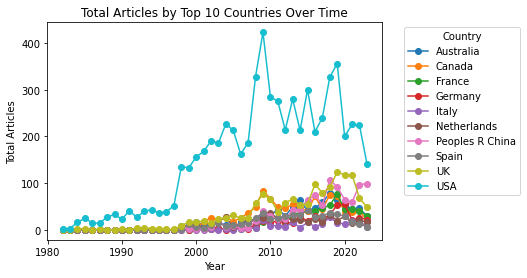

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# 读取数据
country_data = pd.read_csv('./data/all-country.csv')  # 包含国家名称的 CSV 文件路径
year_data = pd.read_excel('./data/pub-year.xlsx')  # 包含出版年份数据的 Excel 文件路径

# 将两个数据集合并
merged_data = pd.merge(country_data, year_data, left_on='Document_ID', right_on='Document_ID')

# 创建文档作者国家的交叉表
cross_table = pd.crosstab(index=[merged_data['Year'], merged_data['Country']], columns='count')

# 计算每个国家的总发文量
total_articles_per_country = cross_table.groupby('Country').sum()

# 选取总发文量前10的国家
top_countries = total_articles_per_country.nlargest(10, 'count').index

# 从合并的数据集中筛选出总发文量前10的国家的数据
top_countries_data = merged_data[merged_data['Country'].isin(top_countries)]

# 创建按国家和年份分组的交叉表
top_countries_cross_table = pd.crosstab(index=top_countries_data['Year'], columns=top_countries_data['Country'])

# 绘制总发文量前10的国家发文量随时间的变化
top_countries_cross_table.plot(kind='line', marker='o')
plt.title('Total Articles by Top 10 Countries Over Time')
plt.xlabel('Year')
plt.ylabel('Total Articles')
plt.legend(title='Country', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


In [12]:
# 将结果保存到 CSV 文件
top_countries_cross_table.to_csv('./data/top10_countries_articles_over_time.csv', index_label='Year')


In [34]:
import pandas as pd
import matplotlib.pyplot as plt

# 读取数据
country_data = pd.read_csv('./data/all-country.csv')  # 包含国家名称的 CSV 文件路径
year_data = pd.read_excel('./data/pub-year.xlsx')  # 包含出版年份数据的 Excel 文件路径

# 将两个数据集合并
merged_data = pd.merge(country_data, year_data, left_on='Document_ID', right_on='Document_ID')

# 创建文档作者国家的交叉表
cross_table = pd.crosstab(index=[merged_data['Year'], merged_data['Country']], columns='count')

# 计算每个国家的总发文量
total_articles_per_country = cross_table.groupby('Country').sum()

# 选取总发文量前10的国家
top_countries = total_articles_per_country.nlargest(20, 'count').index

# 从合并的数据集中筛选出总发文量前10的国家的数据
top_countries_data = merged_data[merged_data['Country'].isin(top_countries)]

# 创建按国家和年份分组的交叉表
top_countries_cross_table = pd.crosstab(index=top_countries_data['Year'], columns=top_countries_data['Country'])

# 将结果保存到 CSV 文件
top_countries_cross_table.to_csv('./data/all_countries_articles_over_time.csv', index_label='Year')

空间分异指数


In [5]:
import pandas as pd
import numpy as np

df = pd.read_csv('./data/all_countries_articles_over_time.csv')
out_df = pd.read_csv('./data/output_with_cv.csv')

# Extract the years and country columns
years = df['Year']
countries = df.iloc[:, 1:]

# 1 Calculate the CV for each year
cv_values = []
for i in range(len(years)):
    x_values = countries.iloc[i, :]
    x_bar = np.mean(x_values)
    n = len(x_values)
    cv = 1 / x_bar * np.sqrt(np.sum((x_values - x_bar) ** 2) / n)
    cv_values.append(cv)

# Add the CV values to the DataFrame
out_df['CV'] = cv_values


# 2 Calculate the Gini coefficient for each year
gini_values = []
for i in range(len(years)):
    x_values = countries.iloc[i, :]
    x_bar = np.mean(x_values)
    n = len(x_values)
    
    gini_sum = 0
    for j in range(n):
        for k in range(n):
            gini_sum += np.abs(x_values[j] - x_values[k])

    gini_coefficient = 1 / (2 * n**2 * x_bar) * gini_sum
    gini_values.append(gini_coefficient)

# Add the Gini coefficient values to the DataFrame
out_df['Gini'] = gini_values

# 3 Calculate the Theil index for each year
theil_values = []
for i in range(len(years)):
    x_values = countries.iloc[i, :]
    x_bar = np.mean(x_values)
    n = len(x_values)
    
    theil_sum = 0
    for j in range(n):
        theil_sum += (x_values[j] / x_bar) * np.log(x_values[j] / x_bar)

    theil_index = 1 / n * theil_sum
    theil_values.append(theil_index)

# Add the Theil index values to the DataFrame
out_df['Theil'] = theil_values

# 4 Calculate the entropy for each year
entropy_values = []
for i in range(len(years)):
    x_values = countries.iloc[i, :]
    total_articles = x_values.sum()
    
    # Calculate the proportion of each country's articles
    P_values = x_values / total_articles
    
    # Calculate the entropy
    entropy = -np.sum(P_values * np.log(P_values))
    entropy_values.append(entropy)

# Add the entropy values to the DataFrame
out_df['Entropy'] = entropy_values


# Save the updated DataFrame to a new CSV file
out_df.to_csv('./data/output_with_cv.csv', index=False)


<ipython-input-5-94d7c341ac9f>:51: RuntimeWarning: divide by zero encountered in log
  theil_sum += (x_values[j] / x_bar) * np.log(x_values[j] / x_bar)
<ipython-input-5-94d7c341ac9f>:51: RuntimeWarning: invalid value encountered in double_scalars
  theil_sum += (x_values[j] / x_bar) * np.log(x_values[j] / x_bar)


In [6]:
import pandas as pd

# Load the CSV file
df = pd.read_csv('./data/all_countries_articles_over_time.csv')

# Define the time intervals
intervals = [(1982, 1992), (1993, 2002), (2003, 2012), (2013, 2023)]

# Create a new column for the interval
df['Interval'] = pd.cut(df['Year'], bins=[1982, 1992, 2002, 2012, 2023], labels=['1982-1992', '1993-2002', '2003-2012', '2013-2023'])

# Group by the interval and sum the article counts for each country
grouped_df = df.groupby(['Interval']).sum().reset_index()

# Drop the 'Year' column as it's no longer needed
grouped_df = grouped_df.drop(columns=['Year'])

# Save the grouped DataFrame to a new CSV file
grouped_df.to_csv('./data/grouped_articles_over_intervals.csv', index=False)


In [8]:
import pandas as pd
import numpy as np

df = pd.read_csv('./data/grouped_articles_over_intervals.csv')
out_df = pd.read_csv('./data/output_with_空间分异.csv')

# Extract the years and country columns
years = df['Interval']
countries = df.iloc[:, 1:]

# 1 Calculate the CV for each year
cv_values = []
for i in range(len(years)):
    x_values = countries.iloc[i, :]
    x_bar = np.mean(x_values)
    n = len(x_values)
    cv = 1 / x_bar * np.sqrt(np.sum((x_values - x_bar) ** 2) / n)
    cv_values.append(cv)

# Add the CV values to the DataFrame
out_df['CV'] = cv_values


# 2 Calculate the Gini coefficient for each year
gini_values = []
for i in range(len(years)):
    x_values = countries.iloc[i, :]
    x_bar = np.mean(x_values)
    n = len(x_values)
    
    gini_sum = 0
    for j in range(n):
        for k in range(n):
            gini_sum += np.abs(x_values[j] - x_values[k])

    gini_coefficient = 1 / (2 * n**2 * x_bar) * gini_sum
    gini_values.append(gini_coefficient)

# Add the Gini coefficient values to the DataFrame
out_df['Gini'] = gini_values

# 3 Calculate the Theil index for each year
theil_values = []
for i in range(len(years)):
    x_values = countries.iloc[i, :]
    x_bar = np.mean(x_values)
    n = len(x_values)
    
    theil_sum = 0
    for j in range(n):
        theil_sum += (x_values[j] / x_bar) * np.log(x_values[j] / x_bar)

    theil_index = 1 / n * theil_sum
    theil_values.append(theil_index)

# Add the Theil index values to the DataFrame
out_df['Theil'] = theil_values

# 4 Calculate the entropy for each year
entropy_values = []
for i in range(len(years)):
    x_values = countries.iloc[i, :]
    total_articles = x_values.sum()
    
    # Calculate the proportion of each country's articles
    P_values = x_values / total_articles
    
    # Calculate the entropy
    entropy = -np.sum(P_values * np.log(P_values))
    entropy_values.append(entropy)

# Add the entropy values to the DataFrame
out_df['Entropy'] = entropy_values


# Save the updated DataFrame to a new CSV file
out_df.to_csv('./data/output_with_空间分异.csv', index=False)

<ipython-input-8-40f9fdde08d6>:51: RuntimeWarning: divide by zero encountered in log
  theil_sum += (x_values[j] / x_bar) * np.log(x_values[j] / x_bar)
<ipython-input-8-40f9fdde08d6>:51: RuntimeWarning: invalid value encountered in double_scalars
  theil_sum += (x_values[j] / x_bar) * np.log(x_values[j] / x_bar)


重心转移

In [108]:
import pandas as pd

# Load the articles data
articles_df = pd.read_csv('./data/all_countries_articles_over_time.csv')
capitals_df = pd.read_csv('./data/capitals.csv')
statistics_df = pd.read_csv('./data/document_statistics_over_time.csv')
# print(articles_df.iloc[1]["Australia"])

# Calculate the weighted coordinates for each year
coordinates = []
latitude=0
longitude=0

for i in range(1,len(articles_df['Year'])):
    for country in capitals_df['Country']: 
        a=float(capitals_df[capitals_df['Country'] == country]['Latitude'])
        b=float(capitals_df[capitals_df['Country'] == country]['Longitude'])
        
        # Calculate the weighted sum of latitude and longitude
        latitude += a * articles_df.iloc[i][country]
        longitude += b* articles_df.iloc[i][country]
    
    weighted_latitude=latitude/statistics_df.iloc[i]['Total Documents']
    weighted_longitude=longitude/statistics_df.iloc[i]['Total Documents']

    coordinates.append({'Year': articles_df.iloc[i]['Year'], 'Weighted Latitude': weighted_latitude, 'Weighted Longitude': weighted_longitude})

# Create a DataFrame from the calculated coordinates
coordinates_df = pd.DataFrame(coordinates).set_index('Year')

# Display or save the resulting DataFrame
print(coordinates_df)
coordinates_df.to_csv('./data/coordinates_shifting.csv')


      Weighted Latitude  Weighted Longitude
Year                                       
1983          23.344320           46.222740
1984          36.619635           63.651117
1985          70.337636          121.082379
1986         134.371674          239.256584
1987         177.820967          312.481183
1988         119.171639          216.158958
1989         107.194550          198.537946
1990         168.512744          310.156423
1991         177.547657          331.622922
1992         235.592905          433.379723
1993         239.096621          434.411572
1994         241.945796          439.451056
1995         305.399200          553.773806
1996         331.184690          603.790788
1997         261.467594          479.883531
1998         127.309924          242.984361
1999         148.931236          279.562172
2000         167.989849          322.541169
2001         183.405191          349.064120
2002         193.337037          368.894784
2003         208.569637         

In [11]:
import pandas as pd

df = pd.read_excel('./data/提取的城市国家信息.xlsx',sheet_name=1,header=None)

countries_dict = {
    'Afghanistan': ['Afghanistan'],
    'Albania': ['Albania'],
    'Algeria': ['Algeria'],
    'Andorra': ['Andorra'],
    'Angola': ['Angola'],
    'Antigua and Barbuda': ['Antigua and Barbuda', 'Antigua', 'Barbuda'],
    'Argentina': ['Argentina'],
    'Armenia': ['Armenia'],
    'Australia': ['Australia'],
    'Austria': ['Austria'],
    'Azerbaijan': ['Azerbaijan', 'Azərbaycan'],
    'Bahamas': ['Bahamas', 'The Bahamas'],
    'Bahrain': ['Bahrain'],
    'Bangladesh': ['Bangladesh'],
    'Barbados': ['Barbados'],
    'Belarus': ['Belarus', 'Belorussia'],
    'Belgium': ['Belgium'],
    'Belize': ['Belize'],
    'Benin': ['Benin'],
    'Bhutan': ['Bhutan'],
    'Bolivia': ['Bolivia'],
    'Bosnia and Herzegovina': ['Bosnia and Herzegovina', 'Bosnia', 'Herzegovina','Bosnia & Herceg'],
    'Botswana': ['Botswana'],
    'Brazil': ['Brazil'],
    'Brunei': ['Brunei', 'Brunei Darussalam'],
    'Bulgaria': ['Bulgaria'],
    'Burkina Faso': ['Burkina Faso'],
    'Burundi': ['Burundi'],
    'Cabo Verde': ['Cabo Verde'],
    'Cambodia': ['Cambodia'],
    'Cameroon': ['Cameroon'],
    'Canada': ['Canada'],
    'Central African Republic': ['Central African Republic', 'CAR'],
    'Chad': ['Chad'],
    'Chile': ['Chile'],
    'China': ['China','Peoples R China'],
    'Colombia': ['Colombia'],
    'Comoros': ['Comoros'],
    'Congo (Congo-Brazzaville)': ['Congo', 'Congo-Brazzaville'],
    'Costa Rica': ['Costa Rica'],
    'Croatia': ['Croatia'],
    'Cuba': ['Cuba'],
    'Cyprus': ['Cyprus'],
    'Czechia (Czech Republic)': ['Czechia', 'Czech Republic'],
    'Denmark': ['Denmark'],
    'Djibouti': ['Djibouti'],
    'Dominica': ['Dominica'],
    'Dominican Republic': ['Dominican Republic'],
    'Ecuador': ['Ecuador'],
    'Egypt': ['Egypt'],
    'El Salvador': ['El Salvador'],
    'Equatorial Guinea': ['Equatorial Guinea', 'Equatorial-Guinea'],
    'Eritrea': ['Eritrea'],
    'Estonia': ['Estonia'],
    'Eswatini': ['Eswatini'],
    'Ethiopia': ['Ethiopia'],
    'Fiji': ['Fiji'],
    'Finland': ['Finland'],
    'France': ['France'],
    'Gabon': ['Gabon'],
    'Gambia': ['Gambia'],
    'Georgia': ['Georgia'],
    'Germany': ['Germany'],
    'Ghana': ['Ghana'],
    'Greece': ['Greece'],
    'Grenada': ['Grenada'],
    'Guatemala': ['Guatemala'],
    'Guinea': ['Guinea'],
    'Guinea-Bissau': ['Guinea-Bissau'],
    'Guyana': ['Guyana'],
    'Haiti': ['Haiti'],
    'Holy See': ['Holy See', 'Vatican City', 'Vatican'],
    'Honduras': ['Honduras'],
    'Hungary': ['Hungary'],
    'Iceland': ['Iceland'],
    'India': ['India'],
    'Indonesia': ['Indonesia'],
    'Iran': ['Iran'],
    'Iraq': ['Iraq'],
    'Ireland': ['Ireland'],
    'Israel': ['Israel'],
    'Italy': ['Italy'],
    'Jamaica': ['Jamaica'],
    'Japan': ['Japan'],
    'Jordan': ['Jordan'],
    'Kazakhstan': ['Kazakhstan'],
    'Kenya': ['Kenya'],
    'Kiribati': ['Kiribati'],
    'Korea, North': ['Korea, North', 'North Korea'],
    'Korea, South': ['Korea, South', 'South Korea'],
    'Kosovo': ['Kosovo'],
    'Kuwait': ['Kuwait'],
    'Kyrgyzstan': ['Kyrgyzstan'],
    'Laos': ['Laos'],
    'Latvia': ['Latvia'],
    'Lebanon': ['Lebanon'],
    'Lesotho': ['Lesotho'],
    'Liberia': ['Liberia'],
    'Libya': ['Libya'],
    'Liechtenstein': ['Liechtenstein'],
    'Lithuania': ['Lithuania'],
    'Luxembourg': ['Luxembourg'],
    'Madagascar': ['Madagascar'],
    'Malawi': ['Malawi'],
    'Malaysia': ['Malaysia'],
    'Maldives': ['Maldives'],
    'Mali': ['Mali'],
    'Malta': ['Malta'],
    'Marshall Islands': ['Marshall Islands'],
    'Mauritania': ['Mauritania'],
    'Mauritius': ['Mauritius'],
    'Mexico': ['Mexico'],
    'Micronesia': ['Micronesia'],
    'Moldova': ['Moldova'],
    'Monaco': ['Monaco'],
    'Mongolia': ['Mongolia'],
    'Montenegro': ['Montenegro'],
    'Morocco': ['Morocco'],
    'Mozambique': ['Mozambique'],
    'Myanmar (formerly Burma)': ['Myanmar', 'Burma'],
    'Namibia': ['Namibia'],
    'Nauru': ['Nauru'],
    'Nepal': ['Nepal'],
    'Netherlands': ['Netherlands'],
    'New Zealand': ['New Zealand'],
    'Nicaragua': ['Nicaragua'],
    'Niger': ['Niger'],
    'Nigeria': ['Nigeria'],
    'North Macedonia (formerly Macedonia)': ['North Macedonia', 'Macedonia'],
    'Norway': ['Norway'],
    'Oman': ['Oman'],
    'Pakistan': ['Pakistan'],
    'Palau': ['Palau'],
    'Palestine State': ['Palestine', 'Palestinian Territories'],
        'Panama': ['Panama'],
    'Papua New Guinea': ['Papua New Guinea'],
    'Paraguay': ['Paraguay'],
    'Peru': ['Peru'],
    'Philippines': ['Philippines'],
    'Poland': ['Poland'],
    'Portugal': ['Portugal'],
    'Qatar': ['Qatar'],
    'Romania': ['Romania'],
    'Russia': ['Russia'],
    'Rwanda': ['Rwanda'],
    'Saint Kitts and Nevis': ['Saint Kitts and Nevis', 'St. Kitts', 'Nevis'],
    'Saint Lucia': ['Saint Lucia', 'St. Lucia'],
    'Saint Vincent and the Grenadines': ['Saint Vincent and the Grenadines', 'St. Vincent', 'Grenadines'],
    'Samoa': ['Samoa'],
    'San Marino': ['San Marino'],
    'Sao Tome and Principe': ['Sao Tome and Principe'],
    'Saudi Arabia': ['Saudi Arabia'],
    'Senegal': ['Senegal'],
    'Serbia': ['Serbia'],
    'Seychelles': ['Seychelles'],
    'Sierra Leone': ['Sierra Leone'],
    'Singapore': ['Singapore'],
    'Slovakia': ['Slovakia'],
    'Slovenia': ['Slovenia'],
    'Solomon Islands': ['Solomon Islands'],
    'Somalia': ['Somalia'],
    'South Africa': ['South Africa'],
    'South Sudan': ['South Sudan'],
    'Spain': ['Spain'],
    'Sri Lanka': ['Sri Lanka'],
    'Sudan': ['Sudan'],
    'Suriname': ['Suriname'],
    'Sweden': ['Sweden'],
    'Switzerland': ['Switzerland'],
    'Syria': ['Syria'],
    'Tajikistan': ['Tajikistan'],
    'Tanzania': ['Tanzania'],
    'Thailand': ['Thailand'],
    'Timor-Leste': ['Timor-Leste'],
    'Togo': ['Togo'],
    'Tonga': ['Tonga'],
    'Trinidad and Tobago': ['Trinidad and Tobago', 'Trinidad', 'Tobago'],
    'Tunisia': ['Tunisia'],
    'Turkey': ['Turkey'],
    'Turkmenistan': ['Turkmenistan'],
    'Tuvalu': ['Tuvalu'],
    'Uganda': ['Uganda'],
    'Ukraine': ['Ukraine'],
    'United Arab Emirates': ['United Arab Emirates', 'UAE'],
    'United Kingdom': ['United Kingdom', 'UK', 'Britain', 'England'],
    'United States': ['United States', 'USA', 'U.S.', 'America'],
    'Uruguay': ['Uruguay'],
    'Uzbekistan': ['Uzbekistan'],
    'Vanuatu': ['Vanuatu'],
    'Venezuela': ['Venezuela'],
    'Vietnam': ['Vietnam'],
    'Yemen': ['Yemen'],
    'Zambia': ['Zambia'],
    'Zimbabwe': ['Zimbabwe'],
    'HONG KONG': ['HONG KONG'],
    'Taiwan': ['Taiwan'],
}


def is_country_name(data):
    # 将所有数据转换为小写，以确保不区分大小写
    data = data.lower()
    
    # 遍历字典中的国家名称
    for country, aliases in countries_dict.items():
        # 将国家名称和别名都转换为小写，以确保不区分大小写
        country = country.lower()
        aliases = [alias.lower() for alias in aliases]
        
        # 检查数据是否是国家名称或其别名之一
        if data == country or data in aliases:
            return True
    
    # 如果没有匹配项，则返回False
    return False


# 示例用法
data_to_check = 'Peoples R China'
if is_country_name(data_to_check):
    print(f"{data_to_check} 是一个国家名称")
else:
    print(f"{data_to_check} 不是一个国家名称")



df['is_country'] = df[1].apply(is_country_name)
print(df['is_country'])
df['is_country'].to_csv('./data/is_country_name.csv')

Peoples R China 是一个国家名称
0        True
1        True
2        True
3        True
4        True
        ...  
1546    False
1547    False
1548    False
1549    False
1550    False
Name: is_country, Length: 1551, dtype: bool


构建美国内部引文网络

In [6]:
import pandas as pd

# 读取sheet1和sheet2的数据
df_sheet1 = pd.read_excel('./data/美国内部引文网络.xlsx', sheet_name='有效state')
df_sheet2 = pd.read_excel('./data/美国内部引文网络.xlsx', sheet_name='引用关系')

# 创建state到state_id的映射
state_id_mapping = {state: idx + 1 for idx, state in enumerate(df_sheet1['state'].unique())}

# 添加state_id列到df_sheet1
df_sheet1['state_id'] = df_sheet1['state'].map(state_id_mapping)

# 将唯一的state和编号输出到CSV文件
unique_states = pd.DataFrame(list(state_id_mapping.items()), columns=['State', 'State_ID'])
# unique_states.to_csv('unique_states.csv', index=False)
print(unique_states)

# 创建文章id到文章id列表的映射，表示每篇文章引用了哪些文章
citation_mapping = df_sheet2.groupby('article_id_1')['article_id_2'].apply(list).to_dict()

# 创建state_id之间的引用关系和引用次数
state_citations = {}
for _, row in df_sheet2.iterrows():
    article_id_1 = row['article_id_1']
    article_id_2 = row['article_id_2']
    
    states_1 = df_sheet1[df_sheet1['article_id'] == article_id_1]['state_id'].tolist()
    states_2 = df_sheet1[df_sheet1['article_id'] == article_id_2]['state_id'].tolist()
    
    for state_1 in states_1:
        for state_2 in states_2:
            citation_pair = tuple(sorted([state_1, state_2]))
            state_citations[citation_pair] = state_citations.get(citation_pair, 0) + 1

# # 输出结果
# for citation_pair, citation_count in state_citations.items():
#     print(f"State Pair: {citation_pair}, Citation Count: {citation_count}")

# 将State Pair和Citation Count存储到CSV文件
citation_df = pd.DataFrame(list(state_citations.items()), columns=['State Pair', 'Citation Count'])
citation_df.to_csv('./data/state_citations.csv', index=False)

   State  State_ID
0     VA         1
1     CA         2
2     ME         3
3     WI         4
4     MA         5
5     OR         6
6     PA         7
7     IL         8
8     AZ         9
9     TX        10
10    CO        11
11    AK        12
12    OH        13
13    IN        14
14    KY        15
15    NY        16
16    NH        17
17    MD        18
18    MI        19
19    WA        20
20    RI        21
21    GA        22
22    DE        23
23    MN        24
24    CT        25
25    MO        26
26    HI        27
27    AL        28
28    SC        29
29    LA        30
30    NM        31
31    NJ        32
32    NC        33
33    UT        34
34    TN        35
35    OK        36
36    MS        37
37    NV        38
38    ND        39
39    ID        40
40    FL        41
41    NE        42
42    AR        43
43    IA        44
44    KS        45
45    WY        46
46    SD        47
47    WV        48
48    MT        49
49    VT        50


In [4]:
import pandas as pd

# 读取CSV文件
data = pd.read_csv('./data/state_citations.csv')

# 创建空的引用关系矩阵
num_states = data['State_id'].nunique()
citation_matrix = pd.DataFrame(0, index=range(num_states), columns=range(num_states))

# 填充引用关系矩阵
for _, row in data.iterrows():
    state_id_1 = row['State_id_1']
    state_id_2 = row['State_id_2']
    citation_count = row['Citation Count']
    
    # 根据州编号填入引用关系矩阵
    citation_matrix.loc[state_id_1-1, state_id_2-1] = citation_count
#     citation_matrix.loc[state_id_2, state_id_1] = citation_count  # 对称矩阵，同时填入反向关系

citation_matrix.to_csv('./data/state_citation_matrix.csv')


# 核心边缘

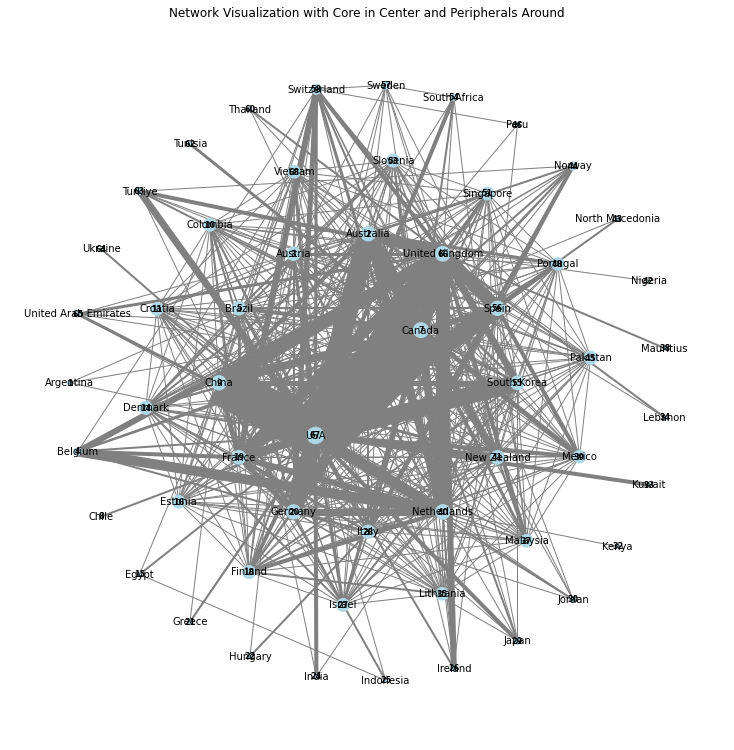

In [2]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# Read node information from Excel file
excel_file_path = "./data/核心边缘/slice3.xlsx"

# Assuming the node information is in the 'Nodes' sheet
node_data = pd.read_excel(excel_file_path, sheet_name='Nodes')

# Assuming the edge information is in the 'Edges' sheet
edge_data = pd.read_excel(excel_file_path, sheet_name='Edges')


# 创建一个空的无向图
G = nx.Graph()

# 添加节点及其属性
for _, row in node_data.iterrows():
    G.add_node(row['id'], label=row['label'], weight=row['weight<core>'], cluster=row['cluster'])

# 添加边及其权重
for _, row in edge_data.iterrows():
    G.add_edge(row['id1'], row['id2'], weight=row['weight'])

# 获取不同类别的节点
core_nodes = [node for node, data in G.nodes(data=True) if data['cluster'] == 1]
strong_peripheral_nodes = [node for node, data in G.nodes(data=True) if data['cluster'] == 2]
semi_peripheral_nodes = [node for node, data in G.nodes(data=True) if data['cluster'] == 3]
edge_nodes = [node for node, data in G.nodes(data=True) if data['cluster'] == 4]

# 将节点按照类别分组
node_groups = [core_nodes, strong_peripheral_nodes, semi_peripheral_nodes, edge_nodes]

# 使用shell布局排列节点
pos = nx.shell_layout(G, node_groups)

# Get node attributes
node_weights = nx.get_node_attributes(G, 'weight')
node_labels = nx.get_node_attributes(G, 'label')

# Get edge attributes
edge_weights = nx.get_edge_attributes(G, 'weight')

# Set node size based on 'weight'
node_sizes = [node_weights[node] * 1000 for node in G.nodes]

# Set edge width based on 'weight'
edge_widths = [edge_weights[edge] for edge in G.edges]

# Draw the network with modified parameters
plt.figure(figsize=(10, 10))
nx.draw(G, pos, with_labels=True, font_size=8, node_color='lightblue', node_size=node_sizes,
        font_color='black', font_weight='bold', edge_color='gray', width=edge_widths)

# Add node labels
node_labels = {node: f"{node_labels[node]}" for node in G.nodes}
nx.draw_networkx_labels(G, pos, labels=node_labels, font_size=10, font_color='black')


plt.title("Network Visualization with Core in Center and Peripherals Around")
plt.show()


In [93]:
# Print node coordinates and write to CSV file
csv_data = {'Node': [], 'X': [], 'Y': []}
for node, coord in pos.items():
    print(f"Node {node}: {coord}")
    csv_data['Node'].append(node)
    csv_data['X'].append(coord[0])
    csv_data['Y'].append(coord[1])

# Create a DataFrame from the dictionary
csv_df = pd.DataFrame(csv_data)

# Write the DataFrame to a CSV file
csv_df.to_csv('./data/核心边缘/node_coordinates.csv', index=False)

Node 48: [0. 0.]
Node 1: [-1.09278471e-08  2.50000000e-01]
Node 41: [-0.21650633 -0.12500004]
Node 47: [ 0.21650639 -0.12499994]
Node 6: [-0.35355338  0.35355338]
Node 8: [-0.49809733  0.04357794]
Node 12: [-0.40957603 -0.2867882 ]
Node 16: [-0.12940949 -0.48296291]
Node 22: [ 0.21130909 -0.45315391]
Node 26: [ 0.45315394 -0.21130902]
Node 28: [0.48296291 0.12940958]
Node 37: [0.28678823 0.40957603]
Node 39: [-0.04357779  0.49809736]
Node 5: [-7.50000000e-01 -6.55670789e-08]
Node 17: [-0.60676271 -0.44083899]
Node 18: [-0.23176284 -0.71329236]
Node 24: [ 0.23176284 -0.71329236]
Node 25: [ 0.60676295 -0.44083869]
Node 27: [7.50000000e-01 1.31134158e-07]
Node 29: [0.60676277 0.44083893]
Node 30: [0.23176259 0.71329248]
Node 32: [-0.23176306  0.71329224]
Node 35: [-0.60676265  0.44083911]


# QAP

合作矩阵

In [9]:
# import pandas as pd
# import numpy as np

# #合作国家
# net_file_path = "./data/核心边缘/slice2.xlsx"
# node_data = pd.read_excel(net_file_path, sheet_name='Nodes')
# edge_data = pd.read_excel(net_file_path, sheet_name='Edges')

# # Merge node and edge data to get cooperation information
# merged_data = pd.merge(edge_data, node_data, left_on='id1', right_on='id')
# merged_data = pd.merge(merged_data, node_data, left_on='id2', right_on='id', suffixes=('_1', '_2'))

# # Extract cooperating country pairs
# cooperation_pairs = merged_data.apply(lambda row: generate_country_pairs(row['label_1'] + ';' + row['label_2']), axis=1)
# cooperation_pairs = [pair for sublist in cooperation_pairs for pair in sublist]

# # Get unique countries
# all_countries = set([country for pair in cooperation_pairs for country in pair])

# # Create a cooperation matrix
# cooperation_matrix = np.zeros((len(all_countries), len(all_countries)))

# # Fill the matrix based on cooperation information
# for pair in cooperation_pairs:
#     idx1 = list(all_countries).index(pair[0])
#     idx2 = list(all_countries).index(pair[1])
#     cooperation_matrix[idx1, idx2] = 1
#     cooperation_matrix[idx2, idx1] = 1

# # Convert the matrix to a DataFrame for better visualization
# cooperation_df = pd.DataFrame(cooperation_matrix, index=list(all_countries), columns=list(all_countries))

# # Display the cooperation matrix
# print(cooperation_df)
# cooperation_df.to_csv("./data/QAP/slice2/cooperation_matrix.csv")

In [1]:
import pandas as pd
import numpy as np

# 定义一个函数来生成国家对
def generate_country_pairs(labels):
    # 假设labels参数是由两个国家标签通过分号连接而成
    countries = labels.split(';')
    # 生成所有可能的配对
    return [(countries[i], countries[j]) for i in range(len(countries)) for j in range(i+1, len(countries))]

# 加载节点和边数据
net_file_path = "./data/核心边缘/slice4.xlsx"
node_data = pd.read_excel(net_file_path, sheet_name='Nodes')
edge_data = pd.read_excel(net_file_path, sheet_name='Edges')

# 合并节点和边数据以获取合作信息
merged_data = pd.merge(edge_data, node_data, left_on='id1', right_on='id', suffixes=('', '_drop'))
merged_data.drop([col for col in merged_data.columns if 'drop' in col], axis=1, inplace=True)
merged_data = pd.merge(merged_data, node_data, left_on='id2', right_on='id', suffixes=('_1', '_2'))

# 提取合作国家对
cooperation_pairs = merged_data.apply(lambda row: generate_country_pairs(row['label_1'] + ';' + row['label_2']), axis=1)
cooperation_pairs = [pair for sublist in cooperation_pairs for pair in sublist]

# 获取所有独特的国家
all_countries = set([country for pair in cooperation_pairs for country in pair])

# 创建合作矩阵
cooperation_matrix = np.zeros((len(all_countries), len(all_countries)))
countries_list = list(all_countries)  # 转换为列表以便索引

# 根据合作信息填充矩阵
for pair in cooperation_pairs:
    idx1 = countries_list.index(pair[0])
    idx2 = countries_list.index(pair[1])
    cooperation_matrix[idx1, idx2] = 1
    cooperation_matrix[idx2, idx1] = 1

# 将矩阵转换为DataFrame以便更好的可视化
cooperation_df = pd.DataFrame(cooperation_matrix, index=countries_list, columns=countries_list)

# 显示合作矩阵
print(cooperation_df)
cooperation_df.to_csv("./data/QAP/slice4/cooperation_matrix.csv")


                        Bangladesh  New Zealand  Bosnia And Herzegovina  \
Bangladesh                     0.0          0.0                     0.0   
New Zealand                    0.0          0.0                     0.0   
Bosnia And Herzegovina         0.0          0.0                     0.0   
Switzerland                    0.0          0.0                     0.0   
Chile                          0.0          0.0                     0.0   
...                            ...          ...                     ...   
Japan                          0.0          0.0                     0.0   
Czech Republic                 0.0          0.0                     0.0   
South Korea                    0.0          1.0                     0.0   
Norway                         0.0          0.0                     0.0   
USA                            1.0          1.0                     0.0   

                        Switzerland  Chile  Mexico  India  Malaysia  Ghana  \
Bangladesh           

In [2]:
import pandas as pd
import numpy as np

# 定义一个函数来生成国家对
def generate_country_pairs(labels):
    # 假设labels参数是由两个国家标签通过分号连接而成
    countries = labels.split(';')
    return [(countries[0], countries[1])]

# 加载节点和边数据
net_file_path = "./data/核心边缘/slice4.xlsx"
node_data = pd.read_excel(net_file_path, sheet_name='Nodes')
edge_data = pd.read_excel(net_file_path, sheet_name='Edges')

# 合并节点和边数据以获取合作信息
merged_data = pd.merge(edge_data, node_data, left_on='id1', right_on='id', suffixes=('', '_drop'))
merged_data.drop([col for col in merged_data.columns if 'drop' in col], axis=1, inplace=True)
merged_data = pd.merge(merged_data, node_data, left_on='id2', right_on='id', suffixes=('_1', '_2'))

# 提取合作国家对
cooperation_pairs = merged_data.apply(lambda row: generate_country_pairs(row['label_1'] + ';' + row['label_2']), axis=1)
cooperation_pairs = [pair for sublist in cooperation_pairs for pair in sublist]

# 获取所有独特的国家
all_countries = set([country for pair in cooperation_pairs for country in pair])

# 创建合作矩阵
cooperation_matrix = np.zeros((len(all_countries), len(all_countries)))
countries_list = list(all_countries)  # 转换为列表以便索引

# 根据合作信息填充矩阵
for _, row in merged_data.iterrows():
    country1 = row['label_1']
    country2 = row['label_2']
    weight = row['weight']  # 假设边数据中有一个权重列

    idx1 = countries_list.index(country1)
    idx2 = countries_list.index(country2)

    # 根据权重累积合作次数
    cooperation_matrix[idx1, idx2] += weight
    cooperation_matrix[idx2, idx1] += weight

# 将矩阵转换为DataFrame以便更好的可视化
cooperation_df = pd.DataFrame(cooperation_matrix, index=countries_list, columns=countries_list)

# 显示合作矩阵
print(cooperation_df)
cooperation_df.to_csv("./data/QAP/slice4/cooperation_matrix_weighted.csv")


                        Bangladesh  New Zealand  Bosnia And Herzegovina  \
Bangladesh                     0.0          0.0                     0.0   
New Zealand                    0.0          0.0                     0.0   
Bosnia And Herzegovina         0.0          0.0                     0.0   
Switzerland                    0.0          0.0                     0.0   
Chile                          0.0          0.0                     0.0   
...                            ...          ...                     ...   
Japan                          0.0          0.0                     0.0   
Czech Republic                 0.0          0.0                     0.0   
South Korea                    0.0          1.0                     0.0   
Norway                         0.0          0.0                     0.0   
USA                            1.0         20.0                     0.0   

                        Switzerland  Chile  Mexico  India  Malaysia  Ghana  \
Bangladesh           

RTA矩阵

In [3]:
import pandas as pd

#合作国家
net_file_path = "./data/核心边缘/slice4.xlsx"
node_data = pd.read_excel(net_file_path, sheet_name='Nodes')
edge_data = pd.read_excel(net_file_path, sheet_name='Edges')

# Merge node and edge data to get cooperation information
merged_data = pd.merge(edge_data, node_data, left_on='id1', right_on='id')
merged_data = pd.merge(merged_data, node_data, left_on='id2', right_on='id', suffixes=('_1', '_2'))

# Extract cooperating country pairs
cooperation_pairs = merged_data.apply(lambda row: generate_country_pairs(row['label_1'] + ';' + row['label_2']), axis=1)
cooperation_pairs = [pair for sublist in cooperation_pairs for pair in sublist]
# Display the result
for pair in cooperation_pairs:
    print(pair)

('Argentina', 'Canada')
('Australia', 'Canada')
('Bangladesh', 'Canada')
('Belgium', 'Canada')
('Brazil', 'Canada')
('Argentina', 'Colombia')
('Australia', 'Colombia')
('Argentina', 'France')
('Australia', 'France')
('Austria', 'France')
('Belgium', 'France')
('Brazil', 'France')
('Cameroon', 'France')
('Canada', 'France')
('China', 'France')
('Colombia', 'France')
('Denmark', 'France')
('Egypt', 'France')
('Finland', 'France')
('Argentina', 'Mexico')
('Belgium', 'Mexico')
('Canada', 'Mexico')
('China', 'Mexico')
('Colombia', 'Mexico')
('Denmark', 'Mexico')
('France', 'Mexico')
('Germany', 'Mexico')
('Ireland', 'Mexico')
('Argentina', 'Spain')
('Australia', 'Spain')
('Belgium', 'Spain')
('Brazil', 'Spain')
('Canada', 'Spain')
('Chile', 'Spain')
('China', 'Spain')
('Colombia', 'Spain')
('Costa Rica', 'Spain')
('Denmark', 'Spain')
('Egypt', 'Spain')
('Finland', 'Spain')
('France', 'Spain')
('Germany', 'Spain')
('India', 'Spain')
('Ireland', 'Spain')
('Israel', 'Spain')
('Italy', 'Spain')

In [4]:
import pandas as pd

#存在区域贸易协定国家对
RTA_file_path = "./data/QAP/区域贸易协定.xlsx"
RTA_data = pd.read_excel(RTA_file_path, sheet_name='slice4')

def generate_country_pairs(country_string):
    # Split the input string into a list of countries, removing leading and trailing whitespaces
    countries = [country.strip() for country in country_string.split(';')]
    
    # Generate all possible pairs of countries
    country_pairs = [(countries[i], countries[j]) for i in range(len(countries)) 
                     for j in range(i+1, len(countries))]
    
    return country_pairs


#应用generate_country_pairs函数
RTA_country_pairs = RTA_data['Original signatories'].apply(generate_country_pairs).tolist()
# 将列表列表平摊为单个国家对列表
RTA_country_pairs = [pair for sublist in RTA_country_pairs for pair in sublist]
# Display the result
for pair in RTA_country_pairs:
    print(pair)


('Costa Rica', 'Guatemala')
('Costa Rica', 'Panama')
('Costa Rica', 'European Free Trade Association (EFTA)')
('Guatemala', 'Panama')
('Guatemala', 'European Free Trade Association (EFTA)')
('Panama', 'European Free Trade Association (EFTA)')
('Australia', 'Solomon Islands')
('Australia', 'Cook Islands')
('Australia', 'Kiribati')
('Australia', 'Nauru')
('Australia', 'Vanuatu')
('Australia', 'New Zealand')
('Australia', 'Niue')
('Australia', 'Tonga')
('Australia', 'Tuvalu')
('Australia', 'Samoa')
('Solomon Islands', 'Cook Islands')
('Solomon Islands', 'Kiribati')
('Solomon Islands', 'Nauru')
('Solomon Islands', 'Vanuatu')
('Solomon Islands', 'New Zealand')
('Solomon Islands', 'Niue')
('Solomon Islands', 'Tonga')
('Solomon Islands', 'Tuvalu')
('Solomon Islands', 'Samoa')
('Cook Islands', 'Kiribati')
('Cook Islands', 'Nauru')
('Cook Islands', 'Vanuatu')
('Cook Islands', 'New Zealand')
('Cook Islands', 'Niue')
('Cook Islands', 'Tonga')
('Cook Islands', 'Tuvalu')
('Cook Islands', 'Samoa')
(

('Italy', 'Slovak Republic')
('Italy', 'Slovenia')
('Italy', 'South Africa')
('Italy', 'Spain')
('Italy', 'Eswatini')
('Italy', 'Sweden')
('Italy', 'United Kingdom')
('Lesotho', 'Latvia')
('Lesotho', 'Lithuania')
('Lesotho', 'Luxembourg')
('Lesotho', 'Malta')
('Lesotho', 'Mozambique')
('Lesotho', 'Namibia')
('Lesotho', 'Netherlands')
('Lesotho', 'Poland')
('Lesotho', 'Portugal')
('Lesotho', 'Romania')
('Lesotho', 'Slovak Republic')
('Lesotho', 'Slovenia')
('Lesotho', 'South Africa')
('Lesotho', 'Spain')
('Lesotho', 'Eswatini')
('Lesotho', 'Sweden')
('Lesotho', 'United Kingdom')
('Latvia', 'Lithuania')
('Latvia', 'Luxembourg')
('Latvia', 'Malta')
('Latvia', 'Mozambique')
('Latvia', 'Namibia')
('Latvia', 'Netherlands')
('Latvia', 'Poland')
('Latvia', 'Portugal')
('Latvia', 'Romania')
('Latvia', 'Slovak Republic')
('Latvia', 'Slovenia')
('Latvia', 'South Africa')
('Latvia', 'Spain')
('Latvia', 'Eswatini')
('Latvia', 'Sweden')
('Latvia', 'United Kingdom')
('Lithuania', 'Luxembourg')
('Lith

In [5]:
import pandas as pd
import numpy as np

# RTA_country_pairs = [('Germany', 'Netherlands'),('Germany', 'Malaysia'),('Germany', 'United Kingdom')]

# Create an RTA matrix
RTA_matrix = np.zeros_like(cooperation_matrix)

# Fill the RTA matrix based on RTA country pairs
for pair in RTA_country_pairs:
    if pair[0] in all_countries and pair[1] in all_countries:
        idx1 = list(all_countries).index(pair[0])
        idx2 = list(all_countries).index(pair[1])
        RTA_matrix[idx1, idx2] = 1
        RTA_matrix[idx2, idx1] = 1

# Convert the RTA matrix to a DataFrame for better visualization
RTA_df = pd.DataFrame(RTA_matrix, index=list(all_countries), columns=list(all_countries))

# Display the RTA matrix
print(RTA_df)
RTA_df.to_csv("./data/QAP/slice4/RTA_matrix.csv")

                        Bangladesh  New Zealand  Bosnia And Herzegovina  \
Bangladesh                     0.0          0.0                     0.0   
New Zealand                    0.0          0.0                     0.0   
Bosnia And Herzegovina         0.0          0.0                     0.0   
Switzerland                    0.0          0.0                     0.0   
Chile                          0.0          1.0                     0.0   
...                            ...          ...                     ...   
Japan                          0.0          1.0                     0.0   
Czech Republic                 0.0          0.0                     0.0   
South Korea                    0.0          0.0                     0.0   
Norway                         0.0          0.0                     0.0   
USA                            0.0          0.0                     0.0   

                        Switzerland  Chile  Mexico  India  Malaysia  Ghana  \
Bangladesh           

地理距离、毗邻、殖民地、语言、法律

In [7]:
import pandas as pd
import numpy as np

# Read cooperation matrix
cooperation_matrix_path = "./data/QAP/slice4/cooperation_matrix.csv"
cooperation_df = pd.read_csv(cooperation_matrix_path, index_col=0)

# Copy the shape of the cooperation matrix to create a distance matrix
distance_matrix = np.zeros_like(cooperation_df)

# Read country code mapping
country_code_path = "./data/QAP/country_code.csv"
country_code_df = pd.read_csv(country_code_path)

# Read distance data
distance_data_path = "./data/QAP/dist_cepii.csv"
distance_data_df = pd.read_csv(distance_data_path)
# distance_data_df = distance_data_df[distance_data_df['year'] == 2002]

# Function to get distance for a pair of countries
def get_distance(country1, country2):
    query = f"(iso_o == '{country1}' and iso_d == '{country2}') or (iso_o == '{country2}' and iso_d == '{country1}')"
    result = distance_data_df.query(query)
    return result['distcap'].values[0] if not result.empty else None

# Iterate over rows and columns of the cooperation matrix
for i in range(len(cooperation_df.index)):
    for j in range(len(cooperation_df.columns)):
        country1 = cooperation_df.index[i].strip()
        country2 = cooperation_df.columns[j].strip()
        
        # Get the country codes from the country_code_df
        code1 = country_code_df[country_code_df['Country Name'] == country1]['Country Code'].values
        code2 = country_code_df[country_code_df['Country Name'] == country2]['Country Code'].values
        
        # Check if both country codes are found
        if len(code1) > 0 and len(code2) > 0:
            code1, code2 = code1[0], code2[0]
            
#             # Get the distance value from the distance data
#             distance_value = np.log(get_distance(code1, code2))

            distance_value = get_distance(code1, code2)
            if distance_value is not None:
                distance_value = np.log(distance_value)
            else:
                distance_value = np.nan
            
            # Fill in the distance_matrix
            distance_matrix[i, j] = distance_value if distance_value is not None else np.nan


# Convert the distance_matrix to a DataFrame
distance_matrix_df = pd.DataFrame(distance_matrix, index=cooperation_df.index, columns=cooperation_df.columns)

# Save the distance matrix to a CSV file
distance_matrix_csv_path = "./data/QAP/slice4/distance_matrix.csv"
distance_matrix_df.to_csv(distance_matrix_csv_path)

# Display the result
print(distance_matrix_df)


                        Bangladesh  New Zealand  Bosnia And Herzegovina  \
Bangladesh                4.960947     9.342329                     0.0   
New Zealand               9.342329     5.272801                     0.0   
Bosnia And Herzegovina    0.000000     0.000000                     0.0   
Switzerland               8.935339     9.852544                     0.0   
Chile                     9.791925     9.120240                     0.0   
...                            ...          ...                     ...   
Japan                     8.497718     9.166987                     0.0   
Czech Republic            0.000000     0.000000                     0.0   
South Korea               0.000000     0.000000                     0.0   
Norway                    8.878870     9.797668                     0.0   
USA                       9.468603     9.562392                     0.0   

                        Switzerland     Chile    Mexico     India  Malaysia  \
Bangladesh          

In [8]:
import pandas as pd
import numpy as np

# Read cooperation matrix
cooperation_matrix_path = "./data/QAP/slice4/cooperation_matrix.csv"
cooperation_df = pd.read_csv(cooperation_matrix_path, index_col=0)

# Copy the shape of the cooperation matrix to create a distance matrix
distance_matrix = np.zeros_like(cooperation_df)

# Read country code mapping
country_code_path = "./data/QAP/country_code.csv"
country_code_df = pd.read_csv(country_code_path)

# Read distance data
distance_data_path = "./data/QAP/dist_cepii.csv"
distance_data_df = pd.read_csv(distance_data_path)
# distance_data_df = distance_data_df[distance_data_df['year'] == 2002]

# Function to get distance for a pair of countries
def get_distance(country1, country2):
    query = f"(iso_o == '{country1}' and iso_d == '{country2}') or (iso_o == '{country2}' and iso_d == '{country1}')"
    result = distance_data_df.query(query)
    return result['contig'].values[0] if not result.empty else None

# Iterate over rows and columns of the cooperation matrix
for i in range(len(cooperation_df.index)):
    for j in range(len(cooperation_df.columns)):
        country1 = cooperation_df.index[i].strip()
        country2 = cooperation_df.columns[j].strip()
        
        # Get the country codes from the country_code_df
        code1 = country_code_df[country_code_df['Country Name'] == country1]['Country Code'].values
        code2 = country_code_df[country_code_df['Country Name'] == country2]['Country Code'].values
        
        # Check if both country codes are found
        if len(code1) > 0 and len(code2) > 0:
            code1, code2 = code1[0], code2[0]
            
            # Get the distance value from the distance data
            distance_value = get_distance(code1, code2)
            
            # Fill in the distance_matrix
            distance_matrix[i, j] = distance_value if distance_value is not None else np.nan


# Convert the distance_matrix to a DataFrame
distance_matrix_df = pd.DataFrame(distance_matrix, index=cooperation_df.index, columns=cooperation_df.columns)

# Save the distance matrix to a CSV file
distance_matrix_csv_path = "./data/QAP/slice4/contig_matrix.csv"
distance_matrix_df.to_csv(distance_matrix_csv_path)

# Display the result
print(distance_matrix_df)


                        Bangladesh  New Zealand  Bosnia And Herzegovina  \
Bangladesh                     0.0          0.0                     0.0   
New Zealand                    0.0          0.0                     0.0   
Bosnia And Herzegovina         0.0          0.0                     0.0   
Switzerland                    0.0          0.0                     0.0   
Chile                          0.0          0.0                     0.0   
...                            ...          ...                     ...   
Japan                          0.0          0.0                     0.0   
Czech Republic                 0.0          0.0                     0.0   
South Korea                    0.0          0.0                     0.0   
Norway                         0.0          0.0                     0.0   
USA                            0.0          0.0                     0.0   

                        Switzerland  Chile  Mexico  India  Malaysia  Ghana  \
Bangladesh           

In [9]:
import pandas as pd
import numpy as np

# Read cooperation matrix
cooperation_matrix_path = "./data/QAP/slice4/cooperation_matrix.csv"
cooperation_df = pd.read_csv(cooperation_matrix_path, index_col=0)

# Copy the shape of the cooperation matrix to create a distance matrix
distance_matrix = np.zeros_like(cooperation_df)

# Read country code mapping
country_code_path = "./data/QAP/country_code.csv"
country_code_df = pd.read_csv(country_code_path)

# Read distance data
distance_data_path = "./data/QAP/dist_cepii.csv"
distance_data_df = pd.read_csv(distance_data_path)
# distance_data_df = distance_data_df[distance_data_df['year'] == 2002]

# Function to get distance for a pair of countries
def get_distance(country1, country2):
    query = f"(iso_o == '{country1}' and iso_d == '{country2}') or (iso_o == '{country2}' and iso_d == '{country1}')"
    result = distance_data_df.query(query)
    return result['colony'].values[0] if not result.empty else None

# Iterate over rows and columns of the cooperation matrix
for i in range(len(cooperation_df.index)):
    for j in range(len(cooperation_df.columns)):
        country1 = cooperation_df.index[i].strip()
        country2 = cooperation_df.columns[j].strip()
        
        # Get the country codes from the country_code_df
        code1 = country_code_df[country_code_df['Country Name'] == country1]['Country Code'].values
        code2 = country_code_df[country_code_df['Country Name'] == country2]['Country Code'].values
        
        # Check if both country codes are found
        if len(code1) > 0 and len(code2) > 0:
            code1, code2 = code1[0], code2[0]
            
            # Get the distance value from the distance data
            distance_value = get_distance(code1, code2)
            
            # Fill in the distance_matrix
            distance_matrix[i, j] = distance_value if distance_value is not None else np.nan


# Convert the distance_matrix to a DataFrame
distance_matrix_df = pd.DataFrame(distance_matrix, index=cooperation_df.index, columns=cooperation_df.columns)

# Save the distance matrix to a CSV file
distance_matrix_csv_path = "./data/QAP/slice4/colony_matrix.csv"
distance_matrix_df.to_csv(distance_matrix_csv_path)

# Display the result
print(distance_matrix_df)


                        Bangladesh  New Zealand  Bosnia And Herzegovina  \
Bangladesh                     0.0          0.0                     0.0   
New Zealand                    0.0          0.0                     0.0   
Bosnia And Herzegovina         0.0          0.0                     0.0   
Switzerland                    0.0          0.0                     0.0   
Chile                          0.0          0.0                     0.0   
...                            ...          ...                     ...   
Japan                          0.0          0.0                     0.0   
Czech Republic                 0.0          0.0                     0.0   
South Korea                    0.0          0.0                     0.0   
Norway                         0.0          0.0                     0.0   
USA                            0.0          0.0                     0.0   

                        Switzerland  Chile  Mexico  India  Malaysia  Ghana  \
Bangladesh           

In [10]:
import pandas as pd
import numpy as np

# Read cooperation matrix
cooperation_matrix_path = "./data/QAP/slice4/cooperation_matrix.csv"
cooperation_df = pd.read_csv(cooperation_matrix_path, index_col=0)

# Copy the shape of the cooperation matrix to create a distance matrix
distance_matrix = np.zeros_like(cooperation_df)

# Read country code mapping
country_code_path = "./data/QAP/country_code.csv"
country_code_df = pd.read_csv(country_code_path)

# Read distance data
distance_data_path = "./data/QAP/dist_cepii.csv"
distance_data_df = pd.read_csv(distance_data_path)
# distance_data_df = distance_data_df[distance_data_df['year'] == 2002]

# Function to get distance for a pair of countries
def get_distance(country1, country2):
    query = f"(iso_o == '{country1}' and iso_d == '{country2}') or (iso_o == '{country2}' and iso_d == '{country1}')"
    result = distance_data_df.query(query)
    return result['comlang_ethno'].values[0] if not result.empty else None

# Iterate over rows and columns of the cooperation matrix
for i in range(len(cooperation_df.index)):
    for j in range(len(cooperation_df.columns)):
        country1 = cooperation_df.index[i].strip()
        country2 = cooperation_df.columns[j].strip()
        
        # Get the country codes from the country_code_df
        code1 = country_code_df[country_code_df['Country Name'] == country1]['Country Code'].values
        code2 = country_code_df[country_code_df['Country Name'] == country2]['Country Code'].values
        
        # Check if both country codes are found
        if len(code1) > 0 and len(code2) > 0:
            code1, code2 = code1[0], code2[0]
            
            # Get the distance value from the distance data
            distance_value = get_distance(code1, code2)
            
            # Fill in the distance_matrix
            distance_matrix[i, j] = distance_value if distance_value is not None else np.nan


# Convert the distance_matrix to a DataFrame
distance_matrix_df = pd.DataFrame(distance_matrix, index=cooperation_df.index, columns=cooperation_df.columns)

# Save the distance matrix to a CSV file
distance_matrix_csv_path = "./data/QAP/slice4/language_matrix.csv"
distance_matrix_df.to_csv(distance_matrix_csv_path)

# Display the result
print(distance_matrix_df)

                        Bangladesh  New Zealand  Bosnia And Herzegovina  \
Bangladesh                     0.0          0.0                     0.0   
New Zealand                    0.0          0.0                     0.0   
Bosnia And Herzegovina         0.0          0.0                     0.0   
Switzerland                    0.0          0.0                     0.0   
Chile                          0.0          0.0                     0.0   
...                            ...          ...                     ...   
Japan                          0.0          0.0                     0.0   
Czech Republic                 0.0          0.0                     0.0   
South Korea                    0.0          0.0                     0.0   
Norway                         0.0          0.0                     0.0   
USA                            0.0          1.0                     0.0   

                        Switzerland  Chile  Mexico  India  Malaysia  Ghana  \
Bangladesh           

In [12]:
import pandas as pd
import numpy as np

# Read cooperation matrix
cooperation_matrix_path = "./data/QAP/slice4/cooperation_matrix.csv"
cooperation_df = pd.read_csv(cooperation_matrix_path, index_col=0)

# Copy the shape of the cooperation matrix to create a distance matrix
distance_matrix = np.zeros_like(cooperation_df)

# Read country code mapping
country_code_path = "./data/QAP/country_code.csv"
country_code_df = pd.read_csv(country_code_path)

# Read distance data
distance_data_path = "./data/QAP/Gravity_V202211.csv"
distance_data_df = pd.read_csv(distance_data_path)
distance_data_df = distance_data_df[distance_data_df['year'] == 2022]

# Function to get distance for a pair of countries
def get_distance(country1, country2):
    query = f"(iso3_o == '{country1}' and iso3_d == '{country2}') or (iso3_o == '{country2}' and iso3_d == '{country1}')"
    result = distance_data_df.query(query)
    return result['comleg_posttrans'].values[0] if not result.empty else None

# Iterate over rows and columns of the cooperation matrix
for i in range(len(cooperation_df.index)):
    for j in range(len(cooperation_df.columns)):
        country1 = cooperation_df.index[i].strip()
        country2 = cooperation_df.columns[j].strip()
        
        # Get the country codes from the country_code_df
        code1 = country_code_df[country_code_df['Country Name'] == country1]['Country Code'].values
        code2 = country_code_df[country_code_df['Country Name'] == country2]['Country Code'].values
        
        # Check if both country codes are found
        if len(code1) > 0 and len(code2) > 0:
            code1, code2 = code1[0], code2[0]
            
            # Get the distance value from the distance data
            distance_value = get_distance(code1, code2)
            
            # Fill in the distance_matrix
            distance_matrix[i, j] = distance_value if distance_value is not None else np.nan

# Convert the distance_matrix to a DataFrame
distance_matrix_df = pd.DataFrame(distance_matrix, index=cooperation_df.index, columns=cooperation_df.columns)

# Display the result
print(distance_matrix_df)

# Save the distance matrix to a CSV file
distance_matrix_csv_path = "./data/QAP/slice4/leg_matrix.csv"
distance_matrix_df.to_csv(distance_matrix_csv_path)

<ipython-input-12-8730941de3e9>:17: DtypeWarning: Columns (40) have mixed types. Specify dtype option on import or set low_memory=False.
  distance_data_df = pd.read_csv(distance_data_path)


                        Bangladesh  New Zealand  Bosnia And Herzegovina  \
Bangladesh                     NaN          NaN                     0.0   
New Zealand                    NaN          NaN                     0.0   
Bosnia And Herzegovina         0.0          0.0                     0.0   
Switzerland                    NaN          NaN                     0.0   
Chile                          NaN          NaN                     0.0   
...                            ...          ...                     ...   
Japan                          NaN          NaN                     0.0   
Czech Republic                 0.0          0.0                     0.0   
South Korea                    0.0          0.0                     0.0   
Norway                         NaN          NaN                     0.0   
USA                            NaN          NaN                     0.0   

                        Switzerland  Chile  Mexico  India  Malaysia  Ghana  \
Bangladesh           

In [126]:
filtered_data = distance_data_df[
    (distance_data_df["country_id_d"] == 'RUS') &
    (distance_data_df["year"] == 2002) &
    (distance_data_df["country_id_o"] == 'CHN')
]["comleg_posttrans"]
print(filtered_data)

759886    0.0
Name: comleg_posttrans, dtype: float64


经济接近性

In [13]:
import pandas as pd
import numpy as np

# Read cooperation matrix
cooperation_matrix_path = "./data/QAP/slice4/cooperation_matrix.csv"
cooperation_df = pd.read_csv(cooperation_matrix_path, index_col=0)

# Copy the shape of the cooperation matrix to create an economy matrix
economy_matrix = np.zeros_like(cooperation_df)

# Read country code mapping
country_code_path = "./data/QAP/country_code.csv"
country_code_df = pd.read_csv(country_code_path)

# Read income group data
income_group_path = "./data/QAP/income group.csv"
income_group_df = pd.read_csv(income_group_path)

# Function to check if two countries belong to the same income group
def same_income_group(country1, country2):
    group1 = income_group_df[income_group_df['Country Code'] == country1]['income_group_2022'].values
    group2 = income_group_df[income_group_df['Country Code'] == country2]['income_group_2022'].values

    return len(group1) > 0 and len(group2) > 0 and group1[0] == group2[0]

# Iterate over rows and columns of the cooperation matrix
for i in range(len(cooperation_df.index)):
    for j in range(len(cooperation_df.columns)):
        country1 = cooperation_df.index[i].strip()
        country2 = cooperation_df.columns[j].strip()

        # Get the country codes from the country_code_df
        code1 = country_code_df[country_code_df['Country Name'] == country1]['Country Code'].values
        code2 = country_code_df[country_code_df['Country Name'] == country2]['Country Code'].values

        # Check if both country codes are found
        if len(code1) > 0 and len(code2) > 0:
            code1, code2 = code1[0], code2[0]

            # Check if countries belong to the same income group
            economy_matrix[i, j] = 1 if same_income_group(code1, code2) else 0

# Convert the economy_matrix to a DataFrame
economy_matrix_df = pd.DataFrame(economy_matrix, index=cooperation_df.index, columns=cooperation_df.columns)

# Display the result
print(economy_matrix_df)

# Save the distance matrix to a CSV file
economy_matrix_csv_path = "./data/QAP/slice4/economy_matrix.csv"
economy_matrix_df.to_csv(economy_matrix_csv_path)

                        Bangladesh  New Zealand  Bosnia And Herzegovina  \
Bangladesh                     1.0          0.0                     0.0   
New Zealand                    0.0          1.0                     0.0   
Bosnia And Herzegovina         0.0          0.0                     0.0   
Switzerland                    0.0          1.0                     0.0   
Chile                          0.0          1.0                     0.0   
...                            ...          ...                     ...   
Japan                          0.0          1.0                     0.0   
Czech Republic                 0.0          0.0                     0.0   
South Korea                    0.0          0.0                     0.0   
Norway                         0.0          1.0                     0.0   
USA                            0.0          1.0                     0.0   

                        Switzerland  Chile  Mexico  India  Malaysia  Ghana  \
Bangladesh           

社会接近性

In [14]:
import pandas as pd
import numpy as np

# Read cooperation matrix
cooperation_matrix_path = "./data/QAP/slice4/cooperation_matrix.csv"
cooperation_df = pd.read_csv(cooperation_matrix_path, index_col=0)

# Copy the shape of the cooperation matrix to create a Socprox matrix
socprox_matrix = np.zeros_like(cooperation_df, dtype=float)

# Calculate Socprox values
for i in range(len(cooperation_df.index)):
    for j in range(len(cooperation_df.columns)):
        q_ij = cooperation_df.iloc[i, j]
        r_i = np.sum(cooperation_df.iloc[i, :])
        s_j = np.sum(cooperation_df.iloc[:, j])

        # Avoid division by zero
        if r_i + s_j - q_ij != 0:
            socprox_matrix[i, j] = q_ij / (r_i + s_j - q_ij)

# Convert the Socprox matrix to a DataFrame
socprox_matrix_df = pd.DataFrame(socprox_matrix, index=cooperation_df.index, columns=cooperation_df.columns)

# Display the Socprox matrix
print(socprox_matrix_df)

# Save the distance matrix to a CSV file
socprox_matrix_csv_path = "./data/QAP/slice4/socprox_matrix.csv"
socprox_matrix_df.to_csv(socprox_matrix_csv_path)

                        Bangladesh  New Zealand  Bosnia And Herzegovina  \
Bangladesh                0.000000     0.000000                     0.0   
New Zealand               0.000000     0.000000                     0.0   
Bosnia And Herzegovina    0.000000     0.000000                     0.0   
Switzerland               0.000000     0.000000                     0.0   
Chile                     0.000000     0.000000                     0.0   
...                            ...          ...                     ...   
Japan                     0.000000     0.000000                     0.0   
Czech Republic            0.000000     0.000000                     0.0   
South Korea               0.000000     0.030303                     0.0   
Norway                    0.000000     0.000000                     0.0   
USA                       0.017857     0.014286                     0.0   

                        Switzerland     Chile    Mexico     India  Malaysia  \
Bangladesh          

科学能力接近性

In [15]:
import pandas as pd
import numpy as np

# Read cooperation matrix
cooperation_matrix_path = "./data/QAP/slice4/cooperation_matrix.csv"
cooperation_df = pd.read_csv(cooperation_matrix_path, index_col=0)

# Copy the shape of the cooperation matrix to create a research matrix
research_matrix = np.zeros_like(cooperation_df)

# Read research group data
research_group_path = "./data/QAP/research group.xlsx"
research_group_df = pd.read_excel(research_group_path, sheet_name='slice3')

# Function to check if two countries belong to the same research group
def same_research_group(country1, country2):
    group1 = research_group_df[research_group_df['Country Name'] == country1]['research_group'].values
    group2 = research_group_df[research_group_df['Country Name'] == country2]['research_group'].values

    return len(group1) > 0 and len(group2) > 0 and group1[0] == group2[0]

# Iterate over rows and columns of the cooperation matrix
for i in range(len(cooperation_df.index)):
    for j in range(len(cooperation_df.columns)):
        country1 = cooperation_df.index[i].strip()
        country2 = cooperation_df.columns[j].strip()

        # Check if countries belong to the same research group
        research_matrix[i, j] = 1 if same_research_group(country1, country2) else 0

# Convert the research_matrix to a DataFrame
research_matrix_df = pd.DataFrame(research_matrix, index=cooperation_df.index, columns=cooperation_df.columns)

# Display the result
print(research_matrix_df)

# Save the distance matrix to a CSV file
research_matrix_csv_path = "./data/QAP/slice4/research_matrix.csv"
research_matrix_df.to_csv(research_matrix_csv_path)

                        Bangladesh  New Zealand  Bosnia And Herzegovina  \
Bangladesh                     0.0          0.0                     0.0   
New Zealand                    0.0          1.0                     0.0   
Bosnia And Herzegovina         0.0          0.0                     0.0   
Switzerland                    0.0          0.0                     0.0   
Chile                          0.0          0.0                     0.0   
...                            ...          ...                     ...   
Japan                          0.0          0.0                     0.0   
Czech Republic                 0.0          0.0                     0.0   
South Korea                    0.0          1.0                     0.0   
Norway                         0.0          0.0                     0.0   
USA                            0.0          0.0                     0.0   

                        Switzerland  Chile  Mexico  India  Malaysia  Ghana  \
Bangladesh           

国际学生

In [13]:
import pandas as pd
import numpy as np

# Read cooperation matrix
cooperation_matrix_path = "./data/QAP/slice4/cooperation_matrix.csv"
cooperation_df = pd.read_csv(cooperation_matrix_path, index_col=0)

# Copy the shape of the cooperation matrix to create a students matrix
students_matrix = np.zeros_like(cooperation_df, dtype=float)

# Read international students data
students_data_path = "./data/QAP/international students.xlsx"
students_data_df = pd.read_excel(students_data_path, sheet_name='slice4')

# Function to get the number of international students between two countries
def get_international_students(country1, country2):
    students_value1 = students_data_df[
        ((students_data_df['Country_o'] == country1) & (students_data_df['Country_d'] == country2)) |
        ((students_data_df['Country_o'] == country2) & (students_data_df['Country_d'] == country1))
    ]['value'].values

    if len(students_value1) > 0:
        return students_value1[0]
    else:
        return np.nan  # Return NaN if no value is found


# Iterate over rows and columns of the cooperation matrix
for i in range(len(cooperation_df.index)):
    for j in range(len(cooperation_df.columns)):
        country1 = cooperation_df.index[i].strip()
        country2 = cooperation_df.columns[j].strip()

        # Get the number of international students and fill in the students matrix symmetrically
        students_value = get_international_students(country1, country2)
        students_matrix[i, j] = students_value
        students_matrix[j, i] = students_value

# Convert the students matrix to a DataFrame
students_matrix_df = pd.DataFrame(students_matrix, index=cooperation_df.index, columns=cooperation_df.columns)

# Display the students matrix
print(students_matrix_df)

# Save the distance matrix to a CSV file
students_matrix_csv_path = "./data/QAP/slice4/students_matrix.csv"
students_matrix_df.to_csv(students_matrix_csv_path)

                        Bangladesh  New Zealand  Bosnia And Herzegovina  \
Bangladesh                     NaN          NaN                     NaN   
New Zealand                    NaN          NaN                     NaN   
Bosnia And Herzegovina         NaN          NaN                     NaN   
Switzerland                    NaN          NaN                     NaN   
Chile                          NaN          NaN                     NaN   
...                            ...          ...                     ...   
Japan                          NaN          NaN                     NaN   
Czech Republic                 NaN          NaN                     NaN   
South Korea                    NaN          NaN                     NaN   
Norway                         NaN          NaN                     NaN   
USA                            NaN          NaN                     NaN   

                        Switzerland  Chile  Mexico   India  Malaysia  Ghana  \
Bangladesh          

控制变量（FTE）

In [2]:
import pandas as pd
import numpy as np

# Read cooperation matrix
cooperation_matrix_path = "./data/QAP/slice4/cooperation_matrix.csv"
cooperation_df = pd.read_csv(cooperation_matrix_path, index_col=0)

# Copy the shape of the cooperation matrix to create an FTE matrix
fte_matrix = np.zeros_like(cooperation_df, dtype=float)

# Read country code mapping
country_code_path = "./data/QAP/country_code.csv"
country_code_df = pd.read_csv(country_code_path)

# Read FTE data
fte_data_path = "./data/QAP/FTE.csv"
fte_data_df = pd.read_csv(fte_data_path)

# Function to calculate Log of the absolute value of the gap between FTE values
def calculate_fte_gap(country1, country2):
    fte1 = fte_data_df[fte_data_df['Country Code'] == country1]['2013-2022'].values
    fte2 = fte_data_df[fte_data_df['Country Code'] == country2]['2013-2022'].values

    # Check if both FTE values are found
    if len(fte1) > 0 and len(fte2) > 0:
        fte1, fte2 = fte1[0], fte2[0]
        
        # Calculate the Log of the absolute value of the gap
        return np.log(np.abs(fte1 - fte2))

    return np.nan  # Return NaN if one or both FTE values are missing

# Iterate over rows and columns of the cooperation matrix
for i in range(len(cooperation_df.index)):
    for j in range(len(cooperation_df.columns)):
        country1 = cooperation_df.index[i].strip()
        country2 = cooperation_df.columns[j].strip()

        # Get the country codes from the country_code_df
        code1 = country_code_df[country_code_df['Country Name'] == country1]['Country Code'].values
        code2 = country_code_df[country_code_df['Country Name'] == country2]['Country Code'].values

        # Check if both country codes are found
        if len(code1) > 0 and len(code2) > 0:
            code1, code2 = code1[0], code2[0]

            # Calculate and fill in the FTE matrix
            fte_matrix[i, j] = calculate_fte_gap(code1, code2)

# Convert the FTE matrix to a DataFrame
fte_matrix_df = pd.DataFrame(fte_matrix, index=cooperation_df.index, columns=cooperation_df.columns)

# Display the FTE matrix
print(fte_matrix_df)

# Save the distance matrix to a CSV file
fte_matrix_csv_path = "./data/QAP/slice4/fte_matrix.csv"
fte_matrix_df.to_csv(fte_matrix_csv_path)

<ipython-input-2-08e77b8bb0b5>:29: RuntimeWarning: divide by zero encountered in log
  return np.log(np.abs(fte1 - fte2))


                        Bangladesh  New Zealand  Bosnia And Herzegovina  \
Bangladesh                    -inf     8.145068                     0.0   
New Zealand               8.145068         -inf                     0.0   
Bosnia And Herzegovina    0.000000     0.000000                     0.0   
Switzerland               8.231064     5.734923                     0.0   
Chile                     5.838172     8.040186                     0.0   
...                            ...          ...                     ...   
Japan                     8.552967     7.459203                     0.0   
Czech Republic            0.000000     0.000000                     0.0   
South Korea               0.000000     0.000000                     0.0   
Norway                    8.539531     7.418545                     0.0   
USA                       8.198797     5.248254                     0.0   

                        Switzerland     Chile    Mexico     India  Malaysia  \
Bangladesh          

控制变量（GERD）

In [8]:
import pandas as pd
import numpy as np

# Read cooperation matrix
cooperation_matrix_path = "./data/QAP/slice3/cooperation_matrix.csv"
cooperation_df = pd.read_csv(cooperation_matrix_path, index_col=0)

# Copy the shape of the cooperation matrix to create a GERD matrix
gerd_matrix = np.zeros_like(cooperation_df, dtype=float)

# Read country code mapping
country_code_path = "./data/QAP/country_code.csv"
country_code_df = pd.read_csv(country_code_path)

# Read GERD data
gerd_data_path = "./data/QAP/GERD.csv"
gerd_data_df = pd.read_csv(gerd_data_path)

# Function to calculate Log of the absolute value of the gap between GERD values
def calculate_gerd_gap(country1, country2):
    gerd1 = gerd_data_df[gerd_data_df['Country Code'] == country1]['2003-2012'].values
    gerd2 = gerd_data_df[gerd_data_df['Country Code'] == country2]['2003-2012'].values

    # Check if both GERD values are found
    if len(gerd1) > 0 and len(gerd2) > 0:
        gerd1, gerd2 = gerd1[0], gerd2[0]
        
        # Calculate the Log of the absolute value of the gap
        return np.log(np.abs(gerd1 - gerd2))

    return np.nan  # Return NaN if one or both GERD values are missing

# Iterate over rows and columns of the cooperation matrix
for i in range(len(cooperation_df.index)):
    for j in range(len(cooperation_df.columns)):
        country1 = cooperation_df.index[i].strip()
        country2 = cooperation_df.columns[j].strip()

        # Get the country codes from the country_code_df
        code1 = country_code_df[country_code_df['Country Name'] == country1]['Country Code'].values
        code2 = country_code_df[country_code_df['Country Name'] == country2]['Country Code'].values

        # Check if both country codes are found
        if len(code1) > 0 and len(code2) > 0:
            code1, code2 = code1[0], code2[0]

            # Calculate and fill in the GERD matrix
            gerd_matrix[i, j] = calculate_gerd_gap(code1, code2)

# Convert the GERD matrix to a DataFrame
gerd_matrix_df = pd.DataFrame(gerd_matrix, index=cooperation_df.index, columns=cooperation_df.columns)

# Display the GERD matrix
print(gerd_matrix_df)

# Save the distance matrix to a CSV file
gerd_matrix_csv_path = "./data/QAP/slice3/gerd_matrix.csv"
gerd_matrix_df.to_csv(gerd_matrix_csv_path)

<ipython-input-8-2e30dd364271>:29: RuntimeWarning: divide by zero encountered in log
  return np.log(np.abs(gerd1 - gerd2))


                      Pakistan  Slovenia    Greece  Lithuania   Tunisia  \
Pakistan                  -inf  0.653326 -0.084711  -0.255176 -0.829896   
Slovenia              0.653326      -inf  0.003140   0.137274  0.395972   
Greece               -0.084711  0.003140      -inf  -1.937957 -0.728394   
Lithuania            -0.255176  0.137274 -1.937957       -inf -1.082682   
Tunisia              -0.829896  0.395972 -0.728394  -1.082682      -inf   
Argentina            -1.092367  0.461531 -0.538956  -0.822439 -2.295877   
India                -0.782411  0.381596 -0.773325  -1.147346 -3.853393   
Austria               1.060168 -0.035695  0.677058   0.747672  0.896399   
Peru                 -2.379059  0.700401  0.011351  -0.142234 -0.637273   
Australia             0.550381 -1.671265 -0.204401  -0.041725  0.260685   
Hungary               0.184069 -0.328749 -1.261174  -0.850225 -0.266567   
Lebanon              -1.523058  0.760790  0.128237  -0.007201 -0.424436   
South Korea           0.0

控制变量（scale）

In [14]:
import pandas as pd  
  
# 读取数据  
country_data = pd.read_csv('./data/all-country - 副本.csv')  
year_data = pd.read_excel('./data/pub-year.xlsx')  

cooperation_matrix_path = "./data/QAP/slice4/cooperation_matrix.csv"  
cooperation_df = pd.read_csv(cooperation_matrix_path, index_col=0)
  
# 将两个数据集合并  
merged_data = pd.merge(country_data, year_data, on='Document_ID')  
  
# 创建文档作者国家的交叉表（这里我们使用groupby和size来计算每个组合的发文量）  
cross_table = merged_data.groupby(['Year', 'Country']).size().reset_index(name='count')  
  
# 计算每个国家的总发文量  
total_articles_per_country = cross_table.groupby('Country')['count'].sum().reset_index()  
  
# 选取总发文量前10的国家  
countries = cooperation_df.index.tolist()
# top_countries = total_articles_per_country.nlargest(10, 'count')['Country'] 
top_countries = countries

# 从合并的数据集中筛选出总发文量前10的国家的数据  
top_countries_data = merged_data[merged_data['Country'].isin(top_countries)]  
  
# 创建按国家和年份分组的交叉表（使用pivot_table）  
top_countries_cross_table = top_countries_data.pivot_table(index='Year', columns='Country', aggfunc='size', fill_value=0)  
print(top_countries_cross_table)

# 将结果保存到 CSV 文件  
top_countries_cross_table.to_csv('./data/QAP/countries_articles_over_time4.csv')

#手动计算区间sum值

Country  Argentina  Australia  Austria  Bangladesh  Belgium  Brazil  Cameroon  \
Year                                                                            
1982             0          0        0           0        0       0         0   
1983             0          0        0           0        0       0         0   
1984             0          0        0           0        0       0         0   
1985             0          0        0           0        0       0         0   
1986             0          0        0           0        0       0         0   
1987             0          0        0           0        0       0         0   
1988             0          0        0           0        0       0         0   
1989             0          0        0           0        0       0         0   
1990             0          0        0           0        0       0         0   
1991             0          0        0           0        0       0         0   
1992             0          

In [15]:
import pandas as pd
import numpy as np

# Read cooperation matrix
cooperation_matrix_path = "./data/QAP/slice4/cooperation_matrix.csv"
cooperation_df = pd.read_csv(cooperation_matrix_path, index_col=0)

# Copy the shape of the cooperation matrix to create a scale matrix
scale_matrix = np.zeros_like(cooperation_df, dtype=float)

# Read scale data
scale_data_path = "./data/QAP/scale.xlsx"
scale_data_df = pd.read_excel(scale_data_path, sheet_name='slice4')

# Function to calculate Log of the absolute value of the gap between scale values
def calculate_scale_gap(country1, country2):
    scale1 = scale_data_df[scale_data_df['Country Name'] == country1]['2013-2022'].values
    scale2 = scale_data_df[scale_data_df['Country Name'] == country2]['2013-2022'].values

    # Check if both scale values are found
    if len(scale1) > 0 and len(scale2) > 0:
        scale1, scale2 = scale1[0], scale2[0]
        
        # Calculate the Log of the absolute value of the gap
        return np.log(np.abs(scale1 - scale2))

    return np.nan  # Return NaN if one or both scale values are missing

# Iterate over rows and columns of the cooperation matrix
for i in range(len(cooperation_df.index)):
    for j in range(len(cooperation_df.columns)):
        country1 = cooperation_df.index[i].strip()
        country2 = cooperation_df.columns[j].strip()

        # Calculate and fill in the scale matrix
        scale_matrix[i, j] = calculate_scale_gap(country1, country2)

# Convert the scale matrix to a DataFrame
scale_matrix_df = pd.DataFrame(scale_matrix, index=cooperation_df.index, columns=cooperation_df.columns)

# Display the scale matrix
print(scale_matrix_df)

# Save the distance matrix to a CSV file
scale_matrix_csv_path = "./data/QAP/slice4/scale_matrix.csv"
scale_matrix_df.to_csv(scale_matrix_csv_path)

<ipython-input-15-e88ce803f6b5>:25: RuntimeWarning: divide by zero encountered in log
  return np.log(np.abs(scale1 - scale2))


                        Bangladesh  New Zealand  Bosnia And Herzegovina  \
Bangladesh                    -inf     4.488636                     NaN   
New Zealand               4.488636         -inf                     NaN   
Bosnia And Herzegovina         NaN          NaN                     NaN   
Switzerland               4.663439     2.833213                     NaN   
Chile                     0.693147     4.465908                     NaN   
...                            ...          ...                     ...   
Japan                     1.791759     4.418841                     NaN   
Czech Republic            1.386294     4.442651                     NaN   
South Korea               4.709530     3.091042                     NaN   
Norway                    3.970292     3.583519                     NaN   
USA                       7.906547     7.873217                     NaN   

                        Switzerland     Chile    Mexico     India  Malaysia  \
Bangladesh          